# Phishing Detection Project (Colab Ready, Broad Curated Dataset Version)

This notebook implements the same controlled multi-modal phishing email detection experiment as the main benchmark notebook, but applies it to a broader curated collection of public phishing-email datasets.

The methodology remains unchanged:
- TF-IDF + URL baseline
- frozen DistilRoBERTa mean-pooled embeddings + URL comparison model
- Logistic Regression as the downstream classifier
- identical URL feature engineering
- the same evaluation metrics

This notebook uses a broader curated dataset collection spanning multiple public sources. This makes it better suited as a robustness and generalisation check across heterogeneous data sources while preserving the same modelling pipeline.


## Output Configuration for Portability

This section centralises the configuration for project outputs and Google Drive integration.

-   `BASE_OUTPUT_DIR`: The primary directory for all local project outputs (datasets, models, results).
-   `SAVE_TO_DRIVE`: Set to `True` to enable saving copies of artefacts and results to your mounted Google Drive, or `False` to only save locally within the Colab instance (which is temporary).

This configuration makes the notebook more portable by allowing easy adjustment of output locations and optional Google Drive usage.

In [1]:
import os
import shutil

# Configuration Variables
IN_COLAB = "COLAB_RELEASE_TAG" in os.environ or "COLAB_GPU" in os.environ
BASE_OUTPUT_DIR = "/content/phishing_project"
SAVE_TO_DRIVE = True

# Derived Paths
PROJECT_ROOT = BASE_OUTPUT_DIR
DATASETS_DIR = os.path.join(PROJECT_ROOT, "data", "datasets")
OUTPUTS_DIR = os.path.join(PROJECT_ROOT, "outputs")

# Google Drive paths
DRIVE_ROOT = "/content/drive/MyDrive/phishing_project_outputs"
DRIVE_OUTPUTS_DIR = DRIVE_ROOT

# Create local directories
os.makedirs(DATASETS_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

print(f"Project Root: {PROJECT_ROOT}")
print(f"Datasets Directory: {DATASETS_DIR}")
print(f"Outputs Directory: {OUTPUTS_DIR}")

# Mount Google Drive safely
mount_point = "/content/drive"

if IN_COLAB and SAVE_TO_DRIVE:
    if os.path.exists(mount_point) and not os.path.ismount(mount_point):
        for item in os.listdir(mount_point):
            item_path = os.path.join(mount_point, item)
            if os.path.isdir(item_path):
                shutil.rmtree(item_path)
            else:
                os.remove(item_path)
        print("Local mount point cleared.")

    from google.colab import drive
    drive.mount(mount_point, force_remount=True)

    os.makedirs(DRIVE_OUTPUTS_DIR, exist_ok=True)
    print(f"Saving to Google Drive is ENABLED. Drive Outputs Directory: {DRIVE_OUTPUTS_DIR}")

elif not SAVE_TO_DRIVE:
    print("Saving to Google Drive is DISABLED. All outputs will be stored locally.")
else:
    print("Saving to Google Drive is ENABLED but not in Colab. Drive paths will not be used.")

Project Root: /content/phishing_project
Datasets Directory: /content/phishing_project/data/datasets
Outputs Directory: /content/phishing_project/outputs
Mounted at /content/drive
Saving to Google Drive is ENABLED. Drive Outputs Directory: /content/drive/MyDrive/phishing_project_outputs


In [2]:
print("Drive mounted:", os.path.exists("/content/drive/MyDrive"))
print("Output folder exists:", os.path.exists(DRIVE_OUTPUTS_DIR))

if os.path.exists(DRIVE_OUTPUTS_DIR):
    print("Saved embedding files:")
    print([f for f in os.listdir(DRIVE_OUTPUTS_DIR) if f.endswith(".npy")])

Drive mounted: True
Output folder exists: True
Saved embedding files:
['X_train_distilroberta_mean_max256_bs16.npy', 'X_test_distilroberta_mean_max256_bs16.npy', 'X_subset_20000_distilroberta_mean_max256_bs16.npy', 'X_source_train_without_CEAS_08_distilroberta_mean_max256_bs16.npy', 'X_source_test_CEAS_08_distilroberta_mean_max256_bs16.npy']


## How To Run this Project in Google Colab

This notebook serves as the primary implementation for the controlled multi-modal phishing email detection experiment. To run this project:

1.  Open this notebook in Google Colab.
2.  Execute all cells sequentially from top to bottom.
3.  The dataset acquisition step will download necessary CSV files from the curated Zenodo collection into the configured directories (`DATASETS_DIR` and `OUTPUTS_DIR`).
4.  The notebook processes and normalises these datasets into a common `text`/`label`/`source_dataset` schema.
5.  The combined dataset is deduplicated and class-balanced before proceeding to train-test splitting.
6.  The core modelling pipeline includes:
    *   TF-IDF + URL baseline
    *   Frozen DistilRoBERTa mean-pooled embeddings + URL comparison model
    *   Logistic Regression as the downstream classifier for both models
7.  The project also includes repeated split robustness checks, computational cost analysis, and error analysis to provide a comprehensive evaluation.

## 1. Dataset acquisition

The following cell downloads the full broad curated subset from the Phishing Email Curated Datasets collection on Zenodo. The collection explicitly states that it curates 11 phishing-email datasets spanning from 1995 to 2022, which gives this notebook broader temporal and source coverage than using only Enron + Nazario directly.

To preserve the current methodology, this notebook still builds a binary phishing-email classification task with raw text and extractable URLs. The broader curated version is best interpreted as a robustness and external-validation experiment on heterogeneous email sources.


In [3]:

# Cell 1: Download selected files from the curated Zenodo collection
import os
import urllib.request

os.makedirs(DATASETS_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# Curated collection (Zenodo)
CURATED_BASE = "https://zenodo.org/records/8339691/files"
SELECTED_FILES = [
    "Enron.csv",
    "Ling.csv",
    "Nazario.csv",
    "Nazario_5.csv",
    "Nigerian_5.csv",
    "Nigerian_Fraud.csv",
    "SpamAssasin.csv",
    "TREC_05.csv",
    "TREC_06.csv",
    "TREC_07.csv",
    "CEAS_08.csv",
]

def download_file(url, dest):
    if os.path.exists(dest):
        print(f"Already exists: {os.path.basename(dest)}")
        return
    print(f"Downloading {os.path.basename(dest)} ...")
    urllib.request.urlretrieve(url, dest)
    print(f"Saved to {dest}")

for fname in SELECTED_FILES:
    url = f"{CURATED_BASE}/{fname}?download=1"
    dest = os.path.join(DATASETS_DIR, fname)
    download_file(url, dest)

print("Datasets directory contents:")
print(os.listdir(DATASETS_DIR))

Saved to /content/phishing_project/data/datasets/Enron.csv
Saved to /content/phishing_project/data/datasets/Ling.csv
Saved to /content/phishing_project/data/datasets/Nazario.csv
Saved to /content/phishing_project/data/datasets/Nazario_5.csv
Saved to /content/phishing_project/data/datasets/Nigerian_5.csv
Saved to /content/phishing_project/data/datasets/Nigerian_Fraud.csv
Saved to /content/phishing_project/data/datasets/SpamAssasin.csv
Saved to /content/phishing_project/data/datasets/TREC_05.csv
Saved to /content/phishing_project/data/datasets/TREC_06.csv
Saved to /content/phishing_project/data/datasets/TREC_07.csv
Saved to /content/phishing_project/data/datasets/CEAS_08.csv
Datasets directory contents:
['Ling.csv', 'CEAS_08.csv', 'TREC_07.csv', 'Nazario_5.csv', 'TREC_06.csv', 'Nazario.csv', 'TREC_05.csv', 'Nigerian_5.csv', 'Nigerian_Fraud.csv', 'Enron.csv', 'SpamAssasin.csv']


## 2. Environment setup

In [4]:
import importlib
import subprocess
import sys

required_packages = {
    "tqdm": "tqdm",
    "bs4": "beautifulsoup4",
    "transformers": "transformers",
    "seaborn": "seaborn"
}

for module_name, package_name in required_packages.items():
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name, "-q"])
        print(f"Installed {package_name}")
    else:
        print(f"{package_name} already available")

tqdm already available
beautifulsoup4 already available
transformers already available
seaborn already available


In [5]:
import os
import re
import email
import mailbox
import urllib.parse
from email import policy
from email.parser import BytesParser

import numpy as np
import pandas as pd
import torch
import joblib
from tqdm.notebook import tqdm

from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, make_scorer
)
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
from scipy.stats import binomtest

from transformers import AutoTokenizer, AutoModel

import time
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

Using device: cuda


## 3. Dataset construction

The next cells load the selected CSV files from the curated Zenodo collection and normalise them into a common schema.

To preserve the project methodology, the combined dataframe is converted into:
- `text`: unified raw email text built from available subject/body/url fields
- `label`: binary target (`0 = legitimate`, `1 = phishing`)
- `source_dataset`: origin file for traceability

The dataset is then deduplicated and balanced before splitting. Because this notebook mixes multiple public sources, it should be interpreted as a broader robustness and generalisation experiment rather than the cleanest possible benchmark.


In [6]:

import glob

TEXT_CANDIDATES = ["text", "Text", "body", "Body", "email", "Email", "content", "Content", "message", "Message"]
SUBJECT_CANDIDATES = ["subject", "Subject"]
URL_CANDIDATES = ["urls", "Urls", "URL", "url", "links", "Links"]
LABEL_CANDIDATES = ["label", "Label", "class", "Class", "type", "Type", "category", "Category", "email_type", "Email Type", "outcome", "Outcome", "spam", "Spam", "is_phishing", "Is_Phishing"]

# Default labels for files that are known single-class repositories
DEFAULT_SOURCE_LABELS = {
    "Enron.csv": 0,
    "Nazario.csv": 1,
    "Nazario_5.csv": 1,
    "Nigerian_Fraud.csv": 1,
    "Nigerian_5.csv": 1,
}

PHISHING_TERMS = ["phish", "spam", "scam", "fraud", "malicious", "junk"]
LEGIT_TERMS = ["legit", "ham", "safe", "benign", "normal"]


def first_existing_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


def infer_binary_label(series):
    s = series.astype(str).str.strip().str.lower()

    # Numeric-like labels
    mapped = pd.to_numeric(s, errors="coerce")

    if mapped.notna().mean() > 0.95:
        mapped = mapped.fillna(0).astype(int)
        uniq = sorted(mapped.unique().tolist())

        # Already binary 0/1
        if set(uniq).issubset({0, 1}):
            return mapped

        # Common 1/2 encoding
        if set(uniq) == {1, 2}:
            return mapped.map({1: 0, 2: 1})

        # Common -1/1 encoding
        if set(uniq) == {-1, 1}:
            return mapped.map({-1: 0, 1: 1})

        # Unknown numeric encoding to avoid silently guessing
        print(f"Warning: unknown numeric label encoding found: {uniq}")
        return pd.Series(index=s.index, dtype="float")

    # String-like labels
    result = pd.Series(index=s.index, dtype="float")
    result[s.apply(lambda x: any(term in x for term in PHISHING_TERMS))] = 1
    result[s.apply(lambda x: any(term in x for term in LEGIT_TERMS))] = 0

    return result


def build_text(df):
    subject_col = first_existing_column(df, SUBJECT_CANDIDATES)
    text_col = first_existing_column(df, TEXT_CANDIDATES)
    url_col = first_existing_column(df, URL_CANDIDATES)

    parts = []
    if subject_col:
        parts.append(df[subject_col].fillna("").astype(str))
    if text_col:
        parts.append(df[text_col].fillna("").astype(str))
    if url_col:
        parts.append(df[url_col].fillna("").astype(str))

    if not parts:
        # Fallback: use all object columns concatenated
        obj_cols = df.select_dtypes(include=["object"]).columns.tolist()
        if obj_cols:
            parts = [df[c].fillna("").astype(str) for c in obj_cols]
        else:
            return pd.Series([""] * len(df))

    text = parts[0]
    for p in parts[1:]:
        text = text + " " + p
    return text.str.replace(r"\s+", " ", regex=True).str.strip()


def load_curated_csv(path):
    file_name = os.path.basename(path)
    print(f"Loading {file_name} ...")

    try:
        df = pd.read_csv(path)
    except Exception:
        df = pd.read_csv(path, engine="python", on_bad_lines="skip", encoding_errors="ignore")

    label_col = first_existing_column(df, LABEL_CANDIDATES)
    if label_col is not None:
        labels = infer_binary_label(df[label_col])
    else:
        labels = pd.Series([DEFAULT_SOURCE_LABELS.get(file_name, np.nan)] * len(df))

    text = build_text(df)

    out = pd.DataFrame({
        "text": text,
        "label": labels,
        "source_dataset": file_name,
    })

    out = out.dropna(subset=["label"])
    out["label"] = out["label"].astype(int)
    out = out[out["text"].astype(str).str.len() > 20]
    return out.reset_index(drop=True)


In [7]:

curated_paths = [os.path.join(DATASETS_DIR, f) for f in SELECTED_FILES if os.path.exists(os.path.join(DATASETS_DIR, f))]
curated_parts = []
for p in curated_paths:
    try:
        part = load_curated_csv(p)
        if len(part) > 0:
            curated_parts.append(part)
            print(f"  Loaded {len(part)} usable rows from {os.path.basename(p)}")
        else:
            print(f"  No usable rows from {os.path.basename(p)}")
    except Exception as e:
        print(f"  Failed to load {os.path.basename(p)}: {e}")

if not curated_parts:
    raise RuntimeError("No curated datasets could be loaded. Check file availability and column formats.")

df_raw = pd.concat(curated_parts, ignore_index=True)
print("Raw combined dataset shape:", df_raw.shape)
print(df_raw['label'].value_counts(dropna=False))
print(df_raw['source_dataset'].value_counts().head(10))


Loading Enron.csv ...
  Loaded 29756 usable rows from Enron.csv
Loading Ling.csv ...
  Loaded 2859 usable rows from Ling.csv
Loading Nazario.csv ...
  Loaded 1565 usable rows from Nazario.csv
Loading Nazario_5.csv ...
  Loaded 3065 usable rows from Nazario_5.csv
Loading Nigerian_5.csv ...
  Loaded 6330 usable rows from Nigerian_5.csv
Loading Nigerian_Fraud.csv ...
  Loaded 3331 usable rows from Nigerian_Fraud.csv
Loading SpamAssasin.csv ...
  Loaded 5809 usable rows from SpamAssasin.csv
Loading TREC_05.csv ...
  No usable rows from TREC_05.csv
Loading TREC_06.csv ...
  Loaded 16395 usable rows from TREC_06.csv
Loading TREC_07.csv ...
  Loaded 53749 usable rows from TREC_07.csv
Loading CEAS_08.csv ...
  Loaded 39154 usable rows from CEAS_08.csv
Raw combined dataset shape: (162013, 3)
label
1    81157
0    80856
Name: count, dtype: int64
source_dataset
TREC_07.csv           53749
CEAS_08.csv           39154
Enron.csv             29756
TREC_06.csv           16395
Nigerian_5.csv         63

## 4. Source coverage and heterogeneity note

This curated version intentionally mixes multiple public sources to evaluate whether the same TF-IDF + URL and frozen DistilRoBERTa + URL pipeline remains effective across heterogeneous phishing-email datasets.

This broader construction strengthens external validation, but it also introduces more dataset variation than the tighter Enron + Nazario benchmark notebook. For that reason, this notebook is best used as a complementary robustness experiment.


## 5. Text preprocessing and URL feature engineering

This stage cleans the email text and extracts structural URL-based features, which form the second modality used in both models. The URL feature set includes lightweight structural indicators as well as suspicious lexical token cues.

In [8]:
import re
import urllib.parse
import numpy as np
import pandas as pd

def extract_url_features(text):
    """Extract structural and lightweight lexical-risk URL features."""
    url_pattern = r'https?://\S+'
    urls = re.findall(url_pattern, text)

    suspicious_terms = [
        'login', 'verify', 'update', 'secure', 'account', 'bank',
        'confirm', 'password', 'signin', 'pay', 'billing', 'wallet'
    ]

    features = {
        'url_count': 0,
        'avg_url_length': 0,
        'num_dots': 0,
        'num_hyphens': 0,
        'num_digits': 0,
        'has_ip': 0,
        'has_https': 0,
        'num_subdomains': 0,
        'url_ratio': 0,
        'special_chars_count': 0,
        'suspicious_token_count': 0,
        'has_suspicious_token': 0
    }

    valid_urls = []
    special_pattern = r'[!@#$%^&*()_+=\[\]{}|;:,.<>?]'

    for url in urls:
        url = url.rstrip('.,;:!?)"]\'')
        try:
            parsed = urllib.parse.urlparse(url)
        except ValueError:
            continue

        if not parsed.scheme or not parsed.netloc:
            continue

        valid_urls.append(url)
        url_lower = url.lower()

        features['num_dots'] += url.count('.')
        features['num_hyphens'] += url.count('-')
        features['num_digits'] += sum(c.isdigit() for c in url)
        features['special_chars_count'] += len(re.findall(special_pattern, url))

        suspicious_hits = sum(term in url_lower for term in suspicious_terms)
        features['suspicious_token_count'] += suspicious_hits
        if suspicious_hits > 0:
            features['has_suspicious_token'] = 1

        if re.search(r'\b\d{1,3}(?:\.\d{1,3}){3}\b', url):
            features['has_ip'] = 1

        if parsed.scheme == 'https':
            features['has_https'] = 1

        if parsed.hostname:
            features['num_subdomains'] = max(
                features['num_subdomains'],
                max(parsed.hostname.count('.') - 1, 0)
            )

    features['url_count'] = len(valid_urls)

    if valid_urls:
        url_lengths = [len(url) for url in valid_urls]
        features['avg_url_length'] = np.mean(url_lengths)
        total_text_length = len(text)
        total_url_length = sum(url_lengths)
        features['url_ratio'] = total_url_length / total_text_length if total_text_length > 0 else 0

    return features

def create_url_features_df(texts):
    return pd.DataFrame([extract_url_features(str(t)) for t in texts])

In [9]:
def preprocess_text_dedup(text):
    """Stable cleaner for deduplication / overlap checking."""
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = text.replace("&nbsp;", " ").replace("&amp;", "&").replace("&lt;", "<").replace("&gt;", ">")
    text = re.sub(r'\b\d{8,}\b', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def preprocess_text_tfidf(text):
    """Cleaner for TF-IDF baseline."""
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = text.replace("&nbsp;", " ").replace("&amp;", "&").replace("&lt;", "<").replace("&gt;", ">")
    text = re.sub(r'\b\d{8,}\b', ' ', text)
    text = re.sub(r'[^a-z0-9\s\.\,\!\?\:\;\-\@\/_\=\%\']', ' ', text)
    text = re.sub(r'([!?.,])\1+', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def preprocess_text_transformer(text):
    """Cleaner for DistilRoBERTa branch."""
    text = str(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = text.replace("&nbsp;", " ").replace("&amp;", "&").replace("&lt;", "<").replace("&gt;", ">")
    text = re.sub(r'\b\d{8,}\b', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [10]:
print("=" * 60)
print("DEDUPLICATION AND CLASS BALANCING")
print("=" * 60)

def dedup_fingerprint(text):
    text = preprocess_text_dedup(text)
    return f"{len(text)}:{text[:300]}"

df = df_raw.copy()
df['dedup_fp'] = df['text'].apply(dedup_fingerprint)

print(f"Rows before deduplication: {len(df)}")
print("Class distribution before deduplication:")
print(df['label'].value_counts())

df = df.drop_duplicates(subset=['dedup_fp']).reset_index(drop=True)

print(f"\nRows after deduplication: {len(df)}")
print("Class distribution after deduplication:")
print(df['label'].value_counts())

min_class_size = df['label'].value_counts().min()
print(f"\nMinority class size after deduplication: {min_class_size}")

df = (
    df.groupby('label', group_keys=False)
      .apply(lambda x: x.sample(min_class_size, random_state=RANDOM_STATE))
      .reset_index(drop=True)
)

df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
df = df.drop(columns=['dedup_fp'])

print(f"\nRows after rebalancing: {len(df)}")
print("Final class distribution:")
print(df['label'].value_counts())

DEDUPLICATION AND CLASS BALANCING
Rows before deduplication: 162013
Class distribution before deduplication:
label
1    81157
0    80856
Name: count, dtype: int64

Rows after deduplication: 150454
Class distribution after deduplication:
label
0    78422
1    72032
Name: count, dtype: int64

Minority class size after deduplication: 72032

Rows after rebalancing: 144064
Final class distribution:
label
1    72032
0    72032
Name: count, dtype: int64


In [11]:
print("=" * 60)
print("URL FEATURE EXTRACTION")
print("=" * 60)

url_features_df = create_url_features_df(df['text']).reset_index(drop=True)

print(f"URL features created: {url_features_df.shape}")
display(url_features_df.head())

assert len(url_features_df) == len(df), "Mismatch between df and url_features_df"
print("Alignment confirmed between df and url_features_df.")

URL FEATURE EXTRACTION
URL features created: (144064, 12)


,url_count,avg_url_length,num_dots,num_hyphens,num_digits,has_ip,has_https,num_subdomains,url_ratio,special_chars_count,suspicious_token_count,has_suspicious_token
0,1,23.0,1,0,0,0,0,0,0.107981,2,0,0
1,0,0.0,0,0,0,0,0,0,0.000000,0,0,0
2,1,38.0,2,0,0,0,0,1,0.044135,4,0,0
3,1,73.0,3,1,5,0,0,1,0.016824,10,0,0
4,0,0.0,0,0,0,0,0,0,0.000000,0,0,0


Alignment confirmed between df and url_features_df.


### 5.1 URL coverage check

Because the methodology depends on URL-based structural features, it is important to verify that the dataset contains extractable URLs in a meaningful proportion of emails.

In [12]:
url_presence = (url_features_df['url_count'] > 0)
coverage_df = pd.DataFrame({
    'label': df['label'],
    'has_url': url_presence.astype(int),
    'url_count': url_features_df['url_count']
})

overall_coverage = coverage_df['has_url'].mean()
coverage_df['has_suspicious_token'] = url_features_df['has_suspicious_token']
by_class = coverage_df.groupby('label')[['has_url', 'url_count', 'has_suspicious_token']].mean()

print("="*50)
print("URL COVERAGE ANALYSIS")
print("="*50)
print(f"Overall proportion of emails with at least one URL: {overall_coverage:.3f}")
print("\nBy class (0 = legitimate, 1 = phishing):")
display(by_class.rename(columns={
    'has_url': 'proportion_with_url',
    'url_count': 'avg_url_count',
    'has_suspicious_token': 'proportion_with_suspicious_url_token'
}).round(3))

URL COVERAGE ANALYSIS
Overall proportion of emails with at least one URL: 0.439

By class (0 = legitimate, 1 = phishing):


,proportion_with_url,avg_url_count,proportion_with_suspicious_url_token
label,,,
0,0.477,1.821,0.009
1,0.401,0.605,0.004


## 6. Train-test split

PROPER TRAIN/TEST SPLIT (NO LEAKAGE)

- Split by indices BEFORE preprocessing to prevent data leakage.
- This ensures no email appears in both training and test sets.
- Split deduplicated set.

In [13]:


indices = np.arange(len(df))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=RANDOM_STATE, stratify=df['label']
)

X_text_train_raw = df.loc[train_idx, 'text'].values
X_text_test_raw  = df.loc[test_idx,  'text'].values
X_url_train      = url_features_df.loc[train_idx].values
X_url_test       = url_features_df.loc[test_idx].values
y_train          = df.loc[train_idx, 'label'].values
y_test           = df.loc[test_idx,  'label'].values

X_text_train_tfidf = [preprocess_text_tfidf(t) for t in X_text_train_raw]
X_text_test_tfidf  = [preprocess_text_tfidf(t) for t in X_text_test_raw]

X_text_train_transformer = [preprocess_text_transformer(t) for t in X_text_train_raw]
X_text_test_transformer  = [preprocess_text_transformer(t) for t in X_text_test_raw]

print("="*50)
print("DATA SPLIT (NO DATA LEAKAGE)")
print("="*50)
print(f"Training set: {len(X_text_train_raw)} samples")
print(f"Test set:     {len(X_text_test_raw)} samples")
print(f"\nTraining class distribution: {np.bincount(y_train)}")
print(f"Test class distribution:      {np.bincount(y_test)}")

# Leakage verification (raw emails)
def raw_fingerprint(text):
    text = preprocess_text_dedup(text)
    return f"{len(text)}:{text[:300]}"

train_fps = set(raw_fingerprint(t) for t in X_text_train_raw)
test_fps  = set(raw_fingerprint(t) for t in X_text_test_raw)
overlap   = len(train_fps & test_fps)

print(f"\nLeakage check — raw email overlap: {overlap}")
if overlap == 0:
    print("No original email appears in both splits.")
else:
    print(f"WARNING: {overlap} original emails appear in both splits.")


DATA SPLIT (NO DATA LEAKAGE)
Training set: 115251 samples
Test set:     28813 samples

Training class distribution: [57625 57626]
Test class distribution:      [14407 14406]

Leakage check — raw email overlap: 0
No original email appears in both splits.


## 7. Baseline model: TF-IDF + URL

This baseline uses lexical frequency-based text representation combined with the engineered URL features.

In [14]:


tfidf_feature_start = time.perf_counter()

print("="*50)
print("BASELINE FEATURES: TF-IDF + URL")
print("="*50)

# TF-IDF features
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)
X_train_tfidf = tfidf.fit_transform(X_text_train_tfidf)
X_test_tfidf = tfidf.transform(X_text_test_tfidf)

# Standardise URL features for the baseline condition
scaler_url_tfidf = StandardScaler()
X_train_url_scaled_tfidf = scaler_url_tfidf.fit_transform(X_url_train)
X_test_url_scaled_tfidf = scaler_url_tfidf.transform(X_url_test)

# Convert URL features to sparse format for concatenation with TF-IDF
X_train_url_sparse = csr_matrix(X_train_url_scaled_tfidf)
X_test_url_sparse = csr_matrix(X_test_url_scaled_tfidf)

# Combine TF-IDF + URL features
X_train_tfidf_combined = hstack([X_train_tfidf, X_train_url_sparse])
X_test_tfidf_combined = hstack([X_test_tfidf, X_test_url_sparse])
tfidf_feature_time = time.perf_counter() - tfidf_feature_start

print(f"TF-IDF dimensions: {X_train_tfidf.shape[1]}")
print(f"URL feature dimensions: {X_train_url_scaled_tfidf.shape[1]}")
print(f"Combined train shape: {X_train_tfidf_combined.shape}")
print(f"Combined test shape:  {X_test_tfidf_combined.shape}")
print(f"TF-IDF feature preparation time: {tfidf_feature_time:.2f} seconds")


BASELINE FEATURES: TF-IDF + URL
TF-IDF dimensions: 5000
URL feature dimensions: 12
Combined train shape: (115251, 5012)
Combined test shape:  (28813, 5012)
TF-IDF feature preparation time: 74.30 seconds


## 8. Comparison model: frozen DistilRoBERTa mean-pooled embeddings + URL
This comparison model replaces TF-IDF with frozen contextual transformer embeddings aggregated using mean pooling, while keeping the URL features and classifier structure consistent.

In [15]:
distilroberta_feature_start = time.perf_counter()

print("="*50)
print("EXTRACTING / LOADING FROZEN DISTILROBERTA MEAN-POOLED EMBEDDINGS")
print("="*50)

MODEL_NAME = "distilroberta-base"
EMBED_TAG = "distilroberta_mean_max256_bs16"
BATCH_SIZE = 16
MAX_LENGTH = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
distilroberta_model = AutoModel.from_pretrained(MODEL_NAME).to(device)
distilroberta_model.eval()

for param in distilroberta_model.parameters():
    param.requires_grad = False

def get_distilroberta_mean_embeddings(texts, model, tokenizer, batch_size=16, max_length=256):
    """Extract mean-pooled token embeddings from frozen DistilRoBERTa."""
    embeddings = []
    texts = list(texts)

    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc="DistilRoBERTa batches"):
            batch_texts = texts[i:i+batch_size]
            encoded = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            )
            encoded = {k: v.to(device) for k, v in encoded.items()}

            outputs = model(**encoded)
            token_embeddings = outputs.last_hidden_state
            attention_mask = encoded["attention_mask"]

            mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
            masked_embeddings = token_embeddings * mask
            sum_embeddings = masked_embeddings.sum(dim=1)
            sum_mask = mask.sum(dim=1).clamp(min=1e-9)
            mean_embeddings = (sum_embeddings / sum_mask).cpu().numpy()

            embeddings.append(mean_embeddings)

    return np.vstack(embeddings)

# Conditional loading/saving from Google Drive based on SAVE_TO_DRIVE flag
drive_train_embed_path = os.path.join(DRIVE_OUTPUTS_DIR, f"X_train_{EMBED_TAG}.npy")
drive_test_embed_path = os.path.join(DRIVE_OUTPUTS_DIR, f"X_test_{EMBED_TAG}.npy")

X_train_distilroberta = None
X_test_distilroberta = None

if SAVE_TO_DRIVE and os.path.exists(drive_train_embed_path) and os.path.exists(drive_test_embed_path):
    print("Loading saved DistilRoBERTa embeddings from Google Drive...")
    loaded_X_train = np.load(drive_train_embed_path)
    loaded_X_test = np.load(drive_test_embed_path)

    # Shape check to ensure embeddings match current split
    if len(loaded_X_train) == len(X_text_train_transformer) and len(loaded_X_test) == len(X_text_test_transformer):
        X_train_distilroberta = loaded_X_train
        X_test_distilroberta = loaded_X_test
        print("Loaded embeddings match current split.")
    else:
        print("Saved embeddings do not match current split (shape mismatch). Re-extracting...")

if X_train_distilroberta is None or X_test_distilroberta is None:
    print("Saved embeddings not found or mismatched. Extracting DistilRoBERTa embeddings...")
    X_train_distilroberta = get_distilroberta_mean_embeddings(
        X_text_train_transformer, distilroberta_model, tokenizer,
        batch_size=BATCH_SIZE,
        max_length=MAX_LENGTH
    )
    X_test_distilroberta = get_distilroberta_mean_embeddings(
        X_text_test_transformer, distilroberta_model, tokenizer,
        batch_size=BATCH_SIZE,
        max_length=MAX_LENGTH
    )

    if SAVE_TO_DRIVE:
        np.save(drive_train_embed_path, X_train_distilroberta)
        np.save(drive_test_embed_path, X_test_distilroberta)
        print("Saved new embeddings to Google Drive:")
        print(drive_train_embed_path)
        print(drive_test_embed_path)
    else:
        print("Skipped saving new embeddings to Google Drive as SAVE_TO_DRIVE is False.")

distilroberta_feature_time = time.perf_counter() - distilroberta_feature_start

print(f"Train embedding shape: {X_train_distilroberta.shape}")
print(f"Test embedding shape:  {X_test_distilroberta.shape}")
print(f"DistilRoBERTa embedding preparation time: {distilroberta_feature_time:.2f} seconds")
print("\nDistilRoBERTa embeddings ready")

print("="*50)
print("DISTILROBERTA FEATURES: FROZEN DISTILROBERTA MEAN-POOLED EMBEDDINGS + URL")
print("="*50)

scaler_distilroberta = StandardScaler()
X_train_distilroberta_scaled = scaler_distilroberta.fit_transform(X_train_distilroberta)
X_test_distilroberta_scaled = scaler_distilroberta.transform(X_test_distilroberta)

scaler_url_distilroberta = StandardScaler()
X_train_url_scaled_distilroberta = scaler_url_distilroberta.fit_transform(X_url_train)
X_test_url_scaled_distilroberta = scaler_url_distilroberta.transform(X_url_test)

X_train_transformer = np.hstack([X_train_distilroberta_scaled, X_train_url_scaled_distilroberta])
X_test_transformer = np.hstack([X_test_distilroberta_scaled, X_test_url_scaled_distilroberta])

print(f"DistilRoBERTa embedding dimensions: {X_train_distilroberta_scaled.shape[1]}")
print(f"URL feature dimensions: {X_train_url_scaled_distilroberta.shape[1]}")
print(f"Combined train shape: {X_train_transformer.shape}")
print(f"Combined test shape:  {X_test_transformer.shape}")

EXTRACTING / LOADING FROZEN DISTILROBERTA MEAN-POOLED EMBEDDINGS


config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading saved DistilRoBERTa embeddings from Google Drive...
Loaded embeddings match current split.
Train embedding shape: (115251, 768)
Test embedding shape:  (28813, 768)
DistilRoBERTa embedding preparation time: 25.85 seconds

DistilRoBERTa embeddings ready
DISTILROBERTA FEATURES: FROZEN DISTILROBERTA MEAN-POOLED EMBEDDINGS + URL
DistilRoBERTa embedding dimensions: 768
URL feature dimensions: 12
Combined train shape: (115251, 780)
Combined test shape:  (28813, 780)


## 9. Hyperparameter tuning and model fitting

Both models use the same classifier family and are tuned using the same hyperparameter search space. This preserves methodological fairness while allowing each representation to identify its best-performing linear decision boundary under a recall-focused objective. Simple runtime measurements are also recorded to support the feasibility discussion in the dissertation.


In [16]:
print("="*50)
print("HYPERPARAMETER TUNING AND MODEL FITTING")
print("="*50)

param_grid = {
    "C": [0.1, 0.5, 1.0, 5.0, 10.0],
    "solver": ["lbfgs", "liblinear"],
    "max_iter": [1000]
}

recall_scorer = make_scorer(recall_score)

# TF-IDF model
# A fresh estimator instance is used for each grid search so that
#the two tuning runs are fully independent.
print("Tuning TF-IDF + URL model...")
tfidf_tuning_start = time.perf_counter()
grid_tfidf = GridSearchCV(
    estimator=LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=3,
    scoring=recall_scorer,
    n_jobs=-1,
    verbose=1
)
grid_tfidf.fit(X_train_tfidf_combined, y_train)

tfidf_tuning_time = time.perf_counter() - tfidf_tuning_start

clf_tfidf   = grid_tfidf.best_estimator_
tfidf_pred  = clf_tfidf.predict(X_test_tfidf_combined)

tfidf_metrics = {
    "Accuracy":  accuracy_score(y_test, tfidf_pred),
    "Precision": precision_score(y_test, tfidf_pred),
    "Recall":    recall_score(y_test, tfidf_pred),
    "F1-score":  f1_score(y_test, tfidf_pred)
}
tfidf_cm = confusion_matrix(y_test, tfidf_pred)

print(f"Best TF-IDF parameters: {grid_tfidf.best_params_}")
for metric, value in tfidf_metrics.items():
    print(f"  TF-IDF {metric}: {value:.4f}")
print(f"  TF-IDF tuning time: {tfidf_tuning_time:.2f} seconds")

print("\nTuning DistilRoBERTa + URL model...")
distilroberta_tuning_start = time.perf_counter()
grid_distilroberta = GridSearchCV(
    estimator=LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=3,
    scoring=recall_scorer,
    n_jobs=-1,
    verbose=1
)
grid_distilroberta.fit(X_train_transformer, y_train)

distilroberta_tuning_time = time.perf_counter() - distilroberta_tuning_start

clf_distilroberta = grid_distilroberta.best_estimator_
distilroberta_pred = clf_distilroberta.predict(X_test_transformer)

distilroberta_metrics = {
    "Accuracy":  accuracy_score(y_test, distilroberta_pred),
    "Precision": precision_score(y_test, distilroberta_pred),
    "Recall":    recall_score(y_test, distilroberta_pred),
    "F1-score":  f1_score(y_test, distilroberta_pred)
}
distilroberta_cm = confusion_matrix(y_test, distilroberta_pred)

print(f"Best DistilRoBERTa parameters: {grid_distilroberta.best_params_}")
for metric, value in distilroberta_metrics.items():
    print(f"  DistilRoBERTa {metric}: {value:.4f}")
print(f"  DistilRoBERTa tuning time: {distilroberta_tuning_time:.2f} seconds")


HYPERPARAMETER TUNING AND MODEL FITTING
Tuning TF-IDF + URL model...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best TF-IDF parameters: {'C': 10.0, 'max_iter': 1000, 'solver': 'liblinear'}
  TF-IDF Accuracy: 0.9795
  TF-IDF Precision: 0.9773
  TF-IDF Recall: 0.9818
  TF-IDF F1-score: 0.9796
  TF-IDF tuning time: 231.98 seconds

Tuning DistilRoBERTa + URL model...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best DistilRoBERTa parameters: {'C': 0.1, 'max_iter': 1000, 'solver': 'liblinear'}
  DistilRoBERTa Accuracy: 0.9801
  DistilRoBERTa Precision: 0.9797
  DistilRoBERTa Recall: 0.9805
  DistilRoBERTa F1-score: 0.9801
  DistilRoBERTa tuning time: 1265.62 seconds


## 9.1 Save final trained artefacts

In [17]:
print("="*50)
print("SAVING FINAL TRAINED artefacts")
print("="*50)

# Create folders
local_artefacts_dir = os.path.join(OUTPUTS_DIR, "saved_artefacts")

os.makedirs(local_artefacts_dir, exist_ok=True)

# Save TF-IDF branch artefacts locally
joblib.dump(tfidf, os.path.join(local_artefacts_dir, "tfidf_vectorizer.joblib"))
joblib.dump(scaler_url_tfidf, os.path.join(local_artefacts_dir, "tfidf_url_scaler.joblib"))
joblib.dump(clf_tfidf, os.path.join(local_artefacts_dir, "tfidf_logreg_model.joblib"))

# Save DistilRoBERTa branch artefacts locally
joblib.dump(scaler_distilroberta, os.path.join(local_artefacts_dir, "distilroberta_embedding_scaler.joblib"))
joblib.dump(scaler_url_distilroberta, os.path.join(local_artefacts_dir, "distilroberta_url_scaler.joblib"))
joblib.dump(clf_distilroberta, os.path.join(local_artefacts_dir, "distilroberta_logreg_model.joblib"))

print("Saved trained artefacts locally to:", local_artefacts_dir)

if SAVE_TO_DRIVE:
    drive_artefacts_dir = os.path.join(DRIVE_OUTPUTS_DIR, "saved_artefacts")
    os.makedirs(drive_artefacts_dir, exist_ok=True)

    joblib.dump(tfidf, os.path.join(drive_artefacts_dir, "tfidf_vectorizer.joblib"))
    joblib.dump(scaler_url_tfidf, os.path.join(drive_artefacts_dir, "tfidf_url_scaler.joblib"))
    joblib.dump(clf_tfidf, os.path.join(drive_artefacts_dir, "tfidf_logreg_model.joblib"))

    joblib.dump(scaler_distilroberta, os.path.join(drive_artefacts_dir, "distilroberta_embedding_scaler.joblib"))
    joblib.dump(scaler_url_distilroberta, os.path.join(drive_artefacts_dir, "distilroberta_url_scaler.joblib"))
    joblib.dump(clf_distilroberta, os.path.join(drive_artefacts_dir, "distilroberta_logreg_model.joblib"))

    print("Saved trained artefacts to Google Drive:", drive_artefacts_dir)

print("Files saved locally:", os.listdir(local_artefacts_dir))

SAVING FINAL TRAINED artefacts
Saved trained artefacts locally to: /content/phishing_project/outputs/saved_artefacts
Saved trained artefacts to Google Drive: /content/drive/MyDrive/phishing_project_outputs/saved_artefacts
Files saved locally: ['distilroberta_url_scaler.joblib', 'distilroberta_logreg_model.joblib', 'tfidf_vectorizer.joblib', 'tfidf_logreg_model.joblib', 'tfidf_url_scaler.joblib', 'distilroberta_embedding_scaler.joblib']


In [18]:
print("="*50)
print("SAVING HELD-OUT PREDICTIONS")
print("="*50)

predictions_df = pd.DataFrame({
    "y_test": y_test,
    "tfidf_pred": tfidf_pred,
    "distilroberta_pred": distilroberta_pred
})

local_predictions_path = os.path.join(OUTPUTS_DIR, "heldout_predictions.csv")
predictions_df.to_csv(local_predictions_path, index=False)
print("Saved held-out predictions locally to:", local_predictions_path)

if SAVE_TO_DRIVE:
    drive_predictions_path = os.path.join(DRIVE_OUTPUTS_DIR, "heldout_predictions.csv")
    predictions_df.to_csv(drive_predictions_path, index=False)
    print("Saved held-out predictions to Google Drive:", drive_predictions_path)

SAVING HELD-OUT PREDICTIONS
Saved held-out predictions locally to: /content/phishing_project/outputs/heldout_predictions.csv
Saved held-out predictions to Google Drive: /content/drive/MyDrive/phishing_project_outputs/heldout_predictions.csv


## 9.1 McNemar Test
Evaluates whether the two final models differ significantly in their paired held-out test predictions.

In [19]:
print("="*50)
print("MCNEMAR TEST (HELD-OUT TEST SET)")
print("="*50)

def mcnemar_exact_test(y_true, pred_a, pred_b, name_a="Model A", name_b="Model B"):
    # Correct / incorrect flags for each model
    a_correct = (pred_a == y_true)
    b_correct = (pred_b == y_true)

    # Discordant pairs
    b = np.sum(a_correct & ~b_correct)   # A correct, B wrong
    c = np.sum(~a_correct & b_correct)   # A wrong, B correct
    discordant = b + c

    print(f"{name_a} correct, {name_b} wrong: {b}")
    print(f"{name_a} wrong, {name_b} correct: {c}")
    print(f"Total discordant pairs: {discordant}")

    if discordant == 0:
        print("No discordant pairs. McNemar test not applicable.")
        return {
            "Model_A": name_a,
            "Model_B": name_b,
            "A_correct_B_wrong": b,
            "A_wrong_B_correct": c,
            "Discordant_pairs": discordant,
            "McNemar_p_value": 1.0
        }

    # Exact two-sided McNemar via binomial test
    p_value = binomtest(min(b, c), n=discordant, p=0.5, alternative="two-sided").pvalue

    print(f"Exact McNemar p-value: {p_value:.6f}")

    if p_value < 0.05:
        print("Result: statistically significant difference in paired predictions (p < 0.05)")
    else:
        print("Result: no statistically significant difference in paired predictions (p >= 0.05)")

    return {
        "Model_A": name_a,
        "Model_B": name_b,
        "A_correct_B_wrong": b,
        "A_wrong_B_correct": c,
        "Discordant_pairs": discordant,
        "McNemar_p_value": p_value
    }

mcnemar_result = mcnemar_exact_test(
    y_test,
    tfidf_pred,
    distilroberta_pred,
    name_a="TF-IDF + URL",
    name_b="DistilRoBERTa + URL"
)

mcnemar_df = pd.DataFrame([mcnemar_result])
display(mcnemar_df)

MCNEMAR TEST (HELD-OUT TEST SET)
TF-IDF + URL correct, DistilRoBERTa + URL wrong: 409
TF-IDF + URL wrong, DistilRoBERTa + URL correct: 425
Total discordant pairs: 834
Exact McNemar p-value: 0.603503
Result: no statistically significant difference in paired predictions (p >= 0.05)


,Model_A,Model_B,A_correct_B_wrong,A_wrong_B_correct,Discordant_pairs,McNemar_p_value
0,TF-IDF + URL,DistilRoBERTa + URL,409,425,834,0.603503


## 10. Comparative evaluation

In [20]:
comparison_df = pd.DataFrame({
    "Model": ["TF-IDF + URL", "DistilRoBERTa + URL"],
    "Accuracy": [tfidf_metrics["Accuracy"], distilroberta_metrics["Accuracy"]],
    "Precision": [tfidf_metrics["Precision"], distilroberta_metrics["Precision"]],
    "Recall": [tfidf_metrics["Recall"], distilroberta_metrics["Recall"]],
    "F1-score": [tfidf_metrics["F1-score"], distilroberta_metrics["F1-score"]]
})

cost_df = pd.DataFrame({
    "Stage": ["Feature preparation", "Model tuning"],
    "TF-IDF + URL (s)": [tfidf_feature_time, tfidf_tuning_time],
    "DistilRoBERTa + URL (s)": [distilroberta_feature_time, distilroberta_tuning_time]
})

print("="*50)
print("MODEL COMPARISON")
print("="*50)
display(comparison_df.round(4))

print("\nRelative percentage difference (DistilRoBERTa vs TF-IDF):")
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-score']:
    baseline = comparison_df.loc[0, metric]
    distilroberta_val = comparison_df.loc[1, metric]
    improvement = ((distilroberta_val - baseline) / baseline) * 100 if baseline != 0 else float("nan")
    print(f"  {metric}: {improvement:+.2f}%")

best_model = comparison_df.sort_values("Recall", ascending=False).iloc[0]["Model"]
print(f"\nModel with highest phishing recall: {best_model}")

print("\nCOMPUTATIONAL COST COMPARISON")
display(cost_df.round(2))

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-score
0,TF-IDF + URL,0.9795,0.9773,0.9818,0.9796
1,DistilRoBERTa + URL,0.9801,0.9797,0.9805,0.9801



Relative percentage difference (DistilRoBERTa vs TF-IDF):
  Accuracy: +0.06%
  Precision: +0.24%
  Recall: -0.13%
  F1-score: +0.05%

Model with highest phishing recall: TF-IDF + URL

COMPUTATIONAL COST COMPARISON


,Stage,TF-IDF + URL (s),DistilRoBERTa + URL (s)
0,Feature preparation,74.30,25.85
1,Model tuning,231.98,1265.62


### 10.1 Confusion matrix heatmaps

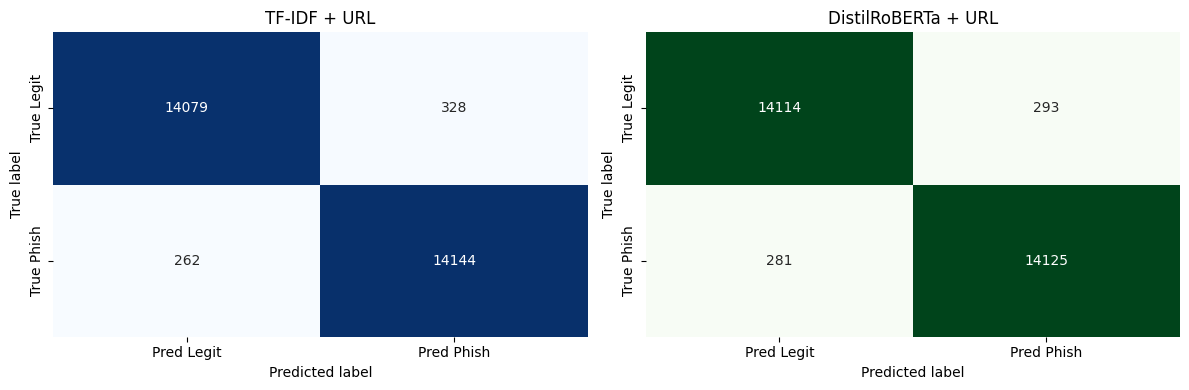

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(tfidf_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred Legit', 'Pred Phish'],
            yticklabels=['True Legit', 'True Phish'],
            ax=axes[0])
axes[0].set_title('TF-IDF + URL')
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')

sns.heatmap(distilroberta_cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Pred Legit', 'Pred Phish'],
            yticklabels=['True Legit', 'True Phish'],
            ax=axes[1])
axes[1].set_title('DistilRoBERTa + URL')
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('True label')

plt.tight_layout()
plt.show()

### 10.2 Results interpretation

At this stage, the comparison is intended to test whether frozen mean-pooled contextual transformer embeddings provide measurable gains over TF-IDF when both models use the same engineered URL features and the same downstream classifier.

The interpretation should therefore focus not only on which model performs better overall, but also on whether any gains in recall and F1-score are large enough to justify the additional computational cost of transformer-based feature extraction. The runtime summary above provides a lightweight empirical basis for that feasibility discussion.

The repeated stratified split evaluation further helps determine whether any observed advantage is stable across multiple train-test partitions rather than being driven by a single favourable split.

A key limitation that should be acknowledged in the write-up is dataset-source heterogeneity: the legitimate and phishing classes are drawn from multiple public corpora, so some learned patterns may reflect source-specific artefacts rather than phishing intent alone.

## 11. Error analysis

In [22]:
print("="*50)
print("ERROR ANALYSIS")
print("="*50)

def error_breakdown(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "Model": model_name,
        "False Positives": fp,
        "False Negatives": fn,
        "Total Errors": fp + fn
    }

error_df = pd.DataFrame([
    error_breakdown(y_test, tfidf_pred, "TF-IDF + URL"),
    error_breakdown(y_test, distilroberta_pred, "DistilRoBERTa + URL"),
])

display(error_df)

# Use RAW emails for readable error examples
X_test_series = pd.Series(X_text_test_raw).reset_index(drop=True)
y_test_series = pd.Series(y_test).reset_index(drop=True)
tfidf_pred_series = pd.Series(tfidf_pred)
distilroberta_pred_series = pd.Series(distilroberta_pred)

def show_examples(y_true, y_pred, title, desired_true, desired_pred, n=2):
    idx = y_true[(y_true == desired_true) & (y_pred == desired_pred)].index[:n]
    print(f"\n{title}")
    print("-" * len(title))
    if len(idx) == 0:
        print("No examples found.")
        return
    for i in idx:
        print(f"Index {i} | True={y_true.iloc[i]} | Pred={y_pred.iloc[i]}")
        print(X_test_series.iloc[i][:500])
        print()

show_examples(y_test_series, tfidf_pred_series, "TF-IDF false negatives", desired_true=1, desired_pred=0)
show_examples(y_test_series, distilroberta_pred_series, "DistilRoBERTa false negatives", desired_true=1, desired_pred=0)
show_examples(y_test_series, tfidf_pred_series, "TF-IDF false positives", desired_true=0, desired_pred=1)
show_examples(y_test_series, distilroberta_pred_series, "DistilRoBERTa false positives", desired_true=0, desired_pred=1)

ERROR ANALYSIS


,Model,False Positives,False Negatives,Total Errors
0,TF-IDF + URL,328,262,590
1,DistilRoBERTa + URL,293,281,574



TF-IDF false negatives
----------------------
Index 86 | True=1 | Pred=0
fwvf SALE 47% OFF Food Network Newsletter This message contains images. If you don't see images, click here to view. August 5, 2008 � � � � Subscribe | Unsubscribe | Change Email Feedback | Questions | User Agreement | Privacy Policy Copyright � 2008 Television Food Network, G.P., All Rights Reserved. � 2008 Scripps Networks Interactive, 9721 Sherrill Blvd., Knoxville, TN 37932 0

Index 219 | True=1 | Pred=0
Mike Bookmark webmark josepht quoter slightly play told wtf. Band blues, junkyard nolan whyte. Lt annonymous kings indeed stuart, thompson, mentioned colors. Collected consent usage measures protect purchase? Michael, buckbee nice together often. Apps liveby sake innovation. Might follow everyones able figure clg, awsome, looking. Spotlight amp dd poorly. Man noticed frankly notice alone ohh counts? Wish richb eg svg, egon readable reader? Tool monopolize, result becomes halfway. Release clinton


DistilRoBER

### 11.1 Robustness check across repeated stratified splits

To strengthen the fairness and stability of the comparison, the experiment is repeated across multiple stratified splits. The same feature definitions, preprocessing rules, classifier family, and fixed best hyperparameters from the main comparison are reused so that the repeated evaluation tests robustness rather than introducing a second tuning process.


In [23]:
print("="*50)
print("ROBUSTNESS CHECK: REPEATED STRATIFIED SPLITS (SUBSET)")
print("="*50)

# Ensure subset_size doesn't exceed the available data
requested_subset_size = 20000
subset_size = min(requested_subset_size, len(df))

# Handle case where subset_size is exactly len(df) to avoid train_test_split error
if subset_size < len(df):
    subset_idx, _ = train_test_split(
        np.arange(len(df)),
        train_size=subset_size,
        random_state=RANDOM_STATE,
        stratify=df['label']
    )
else:
    subset_idx = np.arange(len(df))

df_subset = df.iloc[subset_idx].reset_index(drop=True)
url_features_subset = url_features_df.iloc[subset_idx].reset_index(drop=True)

all_texts_tfidf = [preprocess_text_tfidf(t) for t in df_subset['text'].values]
all_texts_transformer = [preprocess_text_transformer(t) for t in df_subset['text'].values]
y_all = df_subset['label'].values
X_url_all = url_features_subset.values

print(f"Subset size for robustness test: {len(df_subset)} (requested: {requested_subset_size})")
print("Subset class distribution:", np.bincount(y_all))

# Precompute or load frozen DistilRoBERTa embeddings for the subset
distilroberta_repeat_start = time.perf_counter()

subset_embed_path = os.path.join(
    DRIVE_OUTPUTS_DIR,
    f"X_subset_{subset_size}_{EMBED_TAG}.npy"
)

X_all_distilroberta = None

if SAVE_TO_DRIVE and os.path.exists(subset_embed_path):
    print("Loading saved subset DistilRoBERTa embeddings from Google Drive...")
    loaded_subset_embed = np.load(subset_embed_path)
    if len(loaded_subset_embed) == len(all_texts_transformer):
        X_all_distilroberta = loaded_subset_embed
        print("Loaded subset embeddings match current subset size.")
    else:
        print("Saved subset embeddings do not match current subset size. Re-extracting...")

if X_all_distilroberta is None:
    print("Saved subset embeddings not found or mismatched. Extracting...")
    X_all_distilroberta = get_distilroberta_mean_embeddings(
        all_texts_transformer,
        distilroberta_model,
        tokenizer,
        batch_size=BATCH_SIZE,
        max_length=MAX_LENGTH
    )
    if SAVE_TO_DRIVE:
        np.save(subset_embed_path, X_all_distilroberta)
        print("Saved new subset embeddings to:", subset_embed_path)
    else:
        print("Skipped saving new subset embeddings to Google Drive as SAVE_TO_DRIVE is False.")

distilroberta_repeat_time = time.perf_counter() - distilroberta_repeat_start
print(f"Subset DistilRoBERTa embedding preparation time: {distilroberta_repeat_time:.2f} seconds")

rskf = RepeatedStratifiedKFold(n_splits=3, n_repeats=2, random_state=RANDOM_STATE)
robustness_rows = []

for split_id, (train_idx_rep, test_idx_rep) in enumerate(rskf.split(np.zeros(len(y_all)), y_all), start=1):
    X_text_train_rep = [all_texts_tfidf[i] for i in train_idx_rep]
    X_text_test_rep = [all_texts_tfidf[i] for i in test_idx_rep]
    X_url_train_rep = X_url_all[train_idx_rep]
    X_url_test_rep = X_url_all[test_idx_rep]
    y_train_rep = y_all[train_idx_rep]
    y_test_rep = y_all[test_idx_rep]

    # TF-IDF branch
    tfidf_rep = TfidfVectorizer(
        max_features=5000,
        stop_words='english',
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )
    X_train_tfidf_rep = tfidf_rep.fit_transform(X_text_train_rep)
    X_test_tfidf_rep = tfidf_rep.transform(X_text_test_rep)

    scaler_url_tfidf_rep = StandardScaler()
    X_train_url_tfidf_rep = scaler_url_tfidf_rep.fit_transform(X_url_train_rep)
    X_test_url_tfidf_rep = scaler_url_tfidf_rep.transform(X_url_test_rep)

    X_train_tfidf_combined_rep = hstack([X_train_tfidf_rep, csr_matrix(X_train_url_tfidf_rep)])
    X_test_tfidf_combined_rep = hstack([X_test_tfidf_rep, csr_matrix(X_test_url_tfidf_rep)])

    clf_tfidf_rep = LogisticRegression(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        **grid_tfidf.best_params_
    )
    clf_tfidf_rep.fit(X_train_tfidf_combined_rep, y_train_rep)
    tfidf_pred_rep = clf_tfidf_rep.predict(X_test_tfidf_combined_rep)

    tfidf_rep_metrics = {
        'Accuracy': accuracy_score(y_test_rep, tfidf_pred_rep),
        'Precision': precision_score(y_test_rep, tfidf_pred_rep, zero_division=0),
        'Recall': recall_score(y_test_rep, tfidf_pred_rep, zero_division=0),
        'F1-score': f1_score(y_test_rep, tfidf_pred_rep, zero_division=0)
    }

    # DistilRoBERTa branch
    X_train_distilroberta_rep = X_all_distilroberta[train_idx_rep]
    X_test_distilroberta_rep = X_all_distilroberta[test_idx_rep]

    scaler_distilroberta_rep = StandardScaler()
    X_train_distilroberta_scaled_rep = scaler_distilroberta_rep.fit_transform(X_train_distilroberta_rep)
    X_test_distilroberta_scaled_rep = scaler_distilroberta_rep.transform(X_test_distilroberta_rep)

    scaler_url_distilroberta_rep = StandardScaler()
    X_train_url_distilroberta_rep = scaler_url_distilroberta_rep.fit_transform(X_url_train_rep)
    X_test_url_distilroberta_rep = scaler_url_distilroberta_rep.transform(X_url_test_rep)

    X_train_distilroberta_combined_rep = np.hstack([X_train_distilroberta_scaled_rep, X_train_url_distilroberta_rep])
    X_test_distilroberta_combined_rep  = np.hstack([X_test_distilroberta_scaled_rep, X_test_url_distilroberta_rep])

    clf_distilroberta_rep = LogisticRegression(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        **grid_distilroberta.best_params_
    )
    clf_distilroberta_rep.fit(X_train_distilroberta_combined_rep, y_train_rep)
    distilroberta_pred_rep = clf_distilroberta_rep.predict(X_test_distilroberta_combined_rep)

    distilroberta_rep_metrics = {
        'Accuracy': accuracy_score(y_test_rep, distilroberta_pred_rep),
        'Precision': precision_score(y_test_rep, distilroberta_pred_rep, zero_division=0),
        'Recall': recall_score(y_test_rep, distilroberta_pred_rep, zero_division=0),
        'F1-score': f1_score(y_test_rep, distilroberta_pred_rep, zero_division=0)
    }

    for model_name, metrics_dict in [('TF-IDF + URL', tfidf_rep_metrics), ('DistilRoBERTa + URL', distilroberta_rep_metrics)]:
        robustness_rows.append({
            'Split': split_id,
            'Model': model_name,
            **metrics_dict
        })

robustness_df = pd.DataFrame(robustness_rows)
robustness_summary = (
    robustness_df.groupby('Model')[['Accuracy', 'Precision', 'Recall', 'F1-score']]
    .agg(['mean', 'std'])
    .round(4)
)
robustness_summary.columns = [f"{metric}_{stat}" for metric, stat in robustness_summary.columns]
robustness_summary = robustness_summary.reset_index()

display(robustness_summary)

ROBUSTNESS CHECK: REPEATED STRATIFIED SPLITS (SUBSET)
Subset size for robustness test: 20000 (requested: 20000)
Subset class distribution: [10000 10000]
Loading saved subset DistilRoBERTa embeddings from Google Drive...
Loaded subset embeddings match current subset size.
Subset DistilRoBERTa embedding preparation time: 2.88 seconds


,Model,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1-score_mean,F1-score_std
0,DistilRoBERTa + URL,0.9732,0.0019,0.9719,0.0041,0.9746,0.0017,0.9733,0.0018
1,TF-IDF + URL,0.9709,0.0013,0.9694,0.0040,0.9724,0.0047,0.9709,0.0013


In [24]:
print("=" * 60)
print("SOURCE-HELD-OUT GENERALISATION CHECK")
print("=" * 60)

heldout_source = "CEAS_08.csv"

source_train_df = df[df["source_dataset"] != heldout_source].reset_index(drop=True)
source_test_df = df[df["source_dataset"] == heldout_source].reset_index(drop=True)

print(f"Held-out source: {heldout_source}")
print(f"Training samples: {len(source_train_df)}")
print(f"Test samples: {len(source_test_df)}")

print("\nTraining class distribution:")
print(source_train_df["label"].value_counts())

print("\nTest class distribution:")
print(source_test_df["label"].value_counts())

if source_train_df["label"].nunique() < 2:
    raise ValueError("Training set contains only one class. Choose a different held-out source.")

if source_test_df["label"].nunique() < 2:
    print("Warning: test set contains only one class, so precision/recall/F1 may be less informative.")

SOURCE-HELD-OUT GENERALISATION CHECK
Held-out source: CEAS_08.csv
Training samples: 110034
Test samples: 34030

Training class distribution:
label
0    56718
1    53316
Name: count, dtype: int64

Test class distribution:
label
1    18716
0    15314
Name: count, dtype: int64


In [25]:
# Build source-held-out inputs

X_source_train_raw = source_train_df["text"].values
X_source_test_raw = source_test_df["text"].values

y_source_train = source_train_df["label"].values
y_source_test = source_test_df["label"].values

X_source_train_tfidf_text = [preprocess_text_tfidf(t) for t in X_source_train_raw]
X_source_test_tfidf_text = [preprocess_text_tfidf(t) for t in X_source_test_raw]

X_source_train_transformer_text = [preprocess_text_transformer(t) for t in X_source_train_raw]
X_source_test_transformer_text = [preprocess_text_transformer(t) for t in X_source_test_raw]

X_source_train_url = create_url_features_df(X_source_train_raw).values
X_source_test_url = create_url_features_df(X_source_test_raw).values

In [26]:
print("\nTraining TF-IDF + URL source-held-out model...")

tfidf_source = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_source_train_tfidf = tfidf_source.fit_transform(X_source_train_tfidf_text)
X_source_test_tfidf = tfidf_source.transform(X_source_test_tfidf_text)

scaler_source_url_tfidf = StandardScaler()
X_source_train_url_scaled_tfidf = scaler_source_url_tfidf.fit_transform(X_source_train_url)
X_source_test_url_scaled_tfidf = scaler_source_url_tfidf.transform(X_source_test_url)

X_source_train_tfidf_combined = hstack([
    X_source_train_tfidf,
    csr_matrix(X_source_train_url_scaled_tfidf)
])

X_source_test_tfidf_combined = hstack([
    X_source_test_tfidf,
    csr_matrix(X_source_test_url_scaled_tfidf)
])

clf_source_tfidf = LogisticRegression(
    class_weight="balanced",
    random_state=RANDOM_STATE,
    **grid_tfidf.best_params_
)

clf_source_tfidf.fit(X_source_train_tfidf_combined, y_source_train)
source_tfidf_pred = clf_source_tfidf.predict(X_source_test_tfidf_combined)


Training TF-IDF + URL source-held-out model...


In [27]:
print("\nExtracting/loading DistilRoBERTa embeddings for source-held-out model...")

source_train_embed_path = os.path.join(
    DRIVE_OUTPUTS_DIR,
    f"X_source_train_without_{heldout_source.replace('.csv', '')}_{EMBED_TAG}.npy"
)

source_test_embed_path = os.path.join(
    DRIVE_OUTPUTS_DIR,
    f"X_source_test_{heldout_source.replace('.csv', '')}_{EMBED_TAG}.npy"
)

X_source_train_distilroberta = None
X_source_test_distilroberta = None

if SAVE_TO_DRIVE and os.path.exists(source_train_embed_path) and os.path.exists(source_test_embed_path):
    loaded_source_train = np.load(source_train_embed_path)
    loaded_source_test = np.load(source_test_embed_path)

    if len(loaded_source_train) == len(X_source_train_transformer_text) and len(loaded_source_test) == len(X_source_test_transformer_text):
        X_source_train_distilroberta = loaded_source_train
        X_source_test_distilroberta = loaded_source_test
        print("Loaded cached source-held-out embeddings.")
    else:
        print("Cached source-held-out embeddings do not match current data. Re-extracting...")

if X_source_train_distilroberta is None or X_source_test_distilroberta is None:
    X_source_train_distilroberta = get_distilroberta_mean_embeddings(
        X_source_train_transformer_text,
        distilroberta_model,
        tokenizer,
        batch_size=BATCH_SIZE,
        max_length=MAX_LENGTH
    )

    X_source_test_distilroberta = get_distilroberta_mean_embeddings(
        X_source_test_transformer_text,
        distilroberta_model,
        tokenizer,
        batch_size=BATCH_SIZE,
        max_length=MAX_LENGTH
    )

    if SAVE_TO_DRIVE:
        np.save(source_train_embed_path, X_source_train_distilroberta)
        np.save(source_test_embed_path, X_source_test_distilroberta)
        print("Saved source-held-out embeddings to Google Drive.")


Extracting/loading DistilRoBERTa embeddings for source-held-out model...
Loaded cached source-held-out embeddings.


In [28]:
print("\nTraining DistilRoBERTa + URL source-held-out model...")

scaler_source_distilroberta = StandardScaler()
X_source_train_distilroberta_scaled = scaler_source_distilroberta.fit_transform(
    X_source_train_distilroberta
)
X_source_test_distilroberta_scaled = scaler_source_distilroberta.transform(
    X_source_test_distilroberta
)

scaler_source_url_distilroberta = StandardScaler()
X_source_train_url_scaled_distilroberta = scaler_source_url_distilroberta.fit_transform(
    X_source_train_url
)
X_source_test_url_scaled_distilroberta = scaler_source_url_distilroberta.transform(
    X_source_test_url
)

X_source_train_transformer = np.hstack([
    X_source_train_distilroberta_scaled,
    X_source_train_url_scaled_distilroberta
])

X_source_test_transformer = np.hstack([
    X_source_test_distilroberta_scaled,
    X_source_test_url_scaled_distilroberta
])

clf_source_distilroberta = LogisticRegression(
    class_weight="balanced",
    random_state=RANDOM_STATE,
    **grid_distilroberta.best_params_
)

clf_source_distilroberta.fit(X_source_train_transformer, y_source_train)
source_distilroberta_pred = clf_source_distilroberta.predict(X_source_test_transformer)


Training DistilRoBERTa + URL source-held-out model...


In [29]:
source_heldout_results = pd.DataFrame([
    {
        "Held-out source": heldout_source,
        "Model": "TF-IDF + URL",
        "Accuracy": accuracy_score(y_source_test, source_tfidf_pred),
        "Precision": precision_score(y_source_test, source_tfidf_pred, zero_division=0),
        "Recall": recall_score(y_source_test, source_tfidf_pred, zero_division=0),
        "F1-score": f1_score(y_source_test, source_tfidf_pred, zero_division=0),
    },
    {
        "Held-out source": heldout_source,
        "Model": "DistilRoBERTa + URL",
        "Accuracy": accuracy_score(y_source_test, source_distilroberta_pred),
        "Precision": precision_score(y_source_test, source_distilroberta_pred, zero_division=0),
        "Recall": recall_score(y_source_test, source_distilroberta_pred, zero_division=0),
        "F1-score": f1_score(y_source_test, source_distilroberta_pred, zero_division=0),
    }
])

display(source_heldout_results.round(4))

,Held-out source,Model,Accuracy,Precision,Recall,F1-score
0,CEAS_08.csv,TF-IDF + URL,0.8928,0.9265,0.8744,0.8997
1,CEAS_08.csv,DistilRoBERTa + URL,0.9267,0.9569,0.9077,0.9316


## 12. Save results

In [30]:
local_results_path = os.path.join(OUTPUTS_DIR, 'phishing_detection_results.csv')
local_errors_path = os.path.join(OUTPUTS_DIR, 'phishing_detection_error_breakdown.csv')
local_costs_path = os.path.join(OUTPUTS_DIR, 'phishing_detection_cost_comparison.csv')
local_mcnemar_path = os.path.join(OUTPUTS_DIR, "phishing_detection_mcnemar_test.csv")
local_robustness_path = os.path.join(OUTPUTS_DIR,'phishing_detection_repeated_split_summary_subset20000.csv')
local_source_heldout_path = os.path.join(OUTPUTS_DIR, "phishing_detection_source_heldout_results.csv")

comparison_df.to_csv(local_results_path, index=False)
error_df.to_csv(local_errors_path, index=False)
cost_df.to_csv(local_costs_path, index=False)
mcnemar_df.to_csv(local_mcnemar_path, index=False)
robustness_summary.to_csv(local_robustness_path, index=False)
source_heldout_results.to_csv(local_source_heldout_path, index=False)

print("Saved source-held-out results locally to:", local_source_heldout_path)

print("Saved locally to:", OUTPUTS_DIR)

if SAVE_TO_DRIVE:
    drive_results_path = os.path.join(DRIVE_OUTPUTS_DIR, 'phishing_detection_results.csv')
    drive_errors_path = os.path.join(DRIVE_OUTPUTS_DIR, 'phishing_detection_error_breakdown.csv')
    drive_costs_path = os.path.join(DRIVE_OUTPUTS_DIR, 'phishing_detection_cost_comparison.csv')
    drive_mcnemar_path = os.path.join(DRIVE_OUTPUTS_DIR, "phishing_detection_mcnemar_test.csv")
    drive_robustness_path = os.path.join(
        DRIVE_OUTPUTS_DIR,
        'phishing_detection_repeated_split_summary_subset20000.csv'
    )
    drive_source_heldout_path = os.path.join(
        DRIVE_OUTPUTS_DIR,
        "phishing_detection_source_heldout_results.csv"
    )

    comparison_df.to_csv(drive_results_path, index=False)
    error_df.to_csv(drive_errors_path, index=False)
    cost_df.to_csv(drive_costs_path, index=False)
    mcnemar_df.to_csv(drive_mcnemar_path, index=False)
    robustness_summary.to_csv(drive_robustness_path, index=False)
    source_heldout_results.to_csv(drive_source_heldout_path, index=False)

    print("Saved to Google Drive:", DRIVE_OUTPUTS_DIR)
    print(os.listdir(DRIVE_OUTPUTS_DIR))

Saved source-held-out results locally to: /content/phishing_project/outputs/phishing_detection_source_heldout_results.csv
Saved locally to: /content/phishing_project/outputs
Saved to Google Drive: /content/drive/MyDrive/phishing_project_outputs
['X_train_distilroberta_mean_max256_bs16.npy', 'X_test_distilroberta_mean_max256_bs16.npy', 'saved_artifacts', 'X_subset_20000_distilroberta_mean_max256_bs16.npy', 'X_source_train_without_CEAS_08_distilroberta_mean_max256_bs16.npy', 'X_source_test_CEAS_08_distilroberta_mean_max256_bs16.npy', 'saved_artefacts', 'heldout_predictions.csv', 'phishing_detection_results.csv', 'phishing_detection_error_breakdown.csv', 'phishing_detection_cost_comparison.csv', 'phishing_detection_repeated_split_summary_subset20000.csv', 'phishing_detection_mcnemar_test.csv', 'phishing_detection_source_heldout_results.csv']
